In [29]:
!pip install tensorflow
!pip install imbalanced-learn
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix , classification_report
from imblearn.over_sampling import SMOTE
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv("11) customer_ditch.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3301,2636-ALXXZ,Female,1,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.6,Yes
4753,5729-KLZAR,Female,0,Yes,Yes,4,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,80.85,302.75,Yes
6182,2925-VDZHY,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),88.70,6501.35,No
5992,0687-ZVTHB,Male,0,Yes,Yes,65,Yes,Yes,DSL,Yes,...,Yes,No,No,Yes,One year,No,Credit card (automatic),72.45,4653.85,Yes
2122,4123-FCVCB,Female,0,No,No,12,Yes,Yes,DSL,No,...,No,Yes,Yes,Yes,One year,Yes,Mailed check,75.85,854.45,No


In [3]:
df.drop('customerID',axis='columns',inplace=True)
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]
df1 = df[df.TotalCharges!=' ']
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

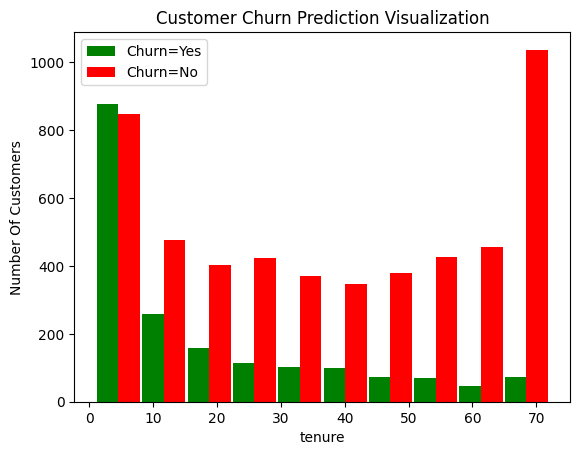

In [6]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure
plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualization")
blood_sugar_men = [113, 85, 90, 150, 149, 88, 93, 115, 135, 80, 77, 82, 129]
blood_sugar_women = [67, 98, 89, 120, 133, 150, 84, 69, 89, 79, 120, 112, 100]
plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()

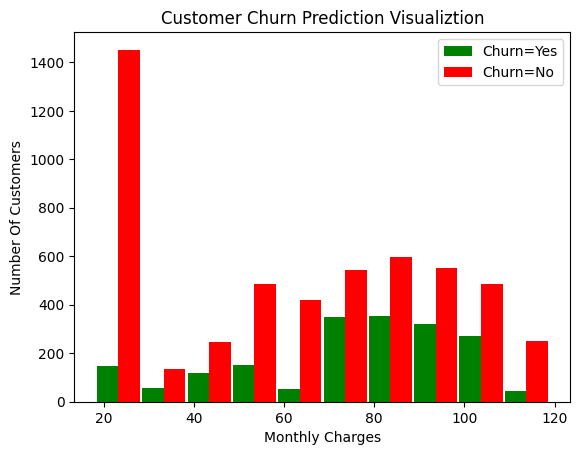

In [7]:
mc_churn_no = df1[df1.Churn=='No'].MonthlyCharges
mc_churn_yes = df1[df1.Churn=='Yes'].MonthlyCharges
plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")
blood_sugar_men = [113, 85, 90, 150, 149, 88, 93, 115, 135, 80, 77, 82, 129]
blood_sugar_women = [67, 98, 89, 120, 133, 150, 84, 69, 89, 79, 120, 112, 100]
plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()

In [8]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [9]:
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [10]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)
for col in df1:
    print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [12]:
df1['gender'].replace({'Female':1,'Male':0},inplace=True)
df1['gender'].unique()

array([1, 0])

In [13]:
df2 = pd.get_dummies(data=df1, columns=['InternetService','Contract','PaymentMethod'])
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [17]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']
scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])
for col in df2:
    print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.         0.46478873 0.01408451 0.61971831 0.09859155 0.29577465
 0.12676056 0.38028169 0.85915493 0.16901408 0.21126761 0.8028169
 0.67605634 0.33802817 0.95774648 0.71830986 0.98591549 0.28169014
 0.15492958 0.4084507  0.64788732 1.         0.22535211 0.36619718
 0.05633803 0.63380282 0.14084507 0.97183099 0.87323944 0.5915493
 0.1971831  0.83098592 0.23943662 0.91549296 0.11267606 0.02816901
 0.42253521 0.69014085 0.88732394 0.77464789 0.08450704 0.57746479
 0.47887324 0.66197183 0.3943662  0.90140845 0.52112676 0.94366197
 0.43661972 0.76056338 0.50704225 0.49295775 0.56338028 0.07042254
 0.04225352 0.45070423 0.92957746 0.30985915 0.78873239 0.84507042
 0.18309859 0.26760563 0.73239437 0.54929577 0.81690141 0.32394366
 0.6056338  0.25352113 0.74647887 0.70422535 0.35211268 0.53521127]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [

In [19]:
X = df2.drop('Churn',axis='columns')
y = testLabels = df2.Churn.astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [23]:
def ANN(X_train, y_train, X_test, y_test, loss, weights):
    model = keras.Sequential([
        keras.layers.Dense(26, input_dim=26, activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    if weights == -1:
        model.fit(X_train, y_train, epochs=100, batch_size=10)
    else:
        model.fit(X_train, y_train, epochs=100, class_weight = weights)
    print(model.evaluate(X_test, y_test))
    y_preds = model.predict(X_test)
    y_preds = np.round(y_preds)
    print("Classification Report: \n", classification_report(y_test, y_preds))
    return y_preds

In [24]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7285 - loss: 0.5312
Epoch 2/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7984 - loss: 0.4257
Epoch 3/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7935 - loss: 0.4239
Epoch 4/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8082 - loss: 0.4138
Epoch 5/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8168 - loss: 0.4095
Epoch 6/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8118 - loss: 0.3947
Epoch 7/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8086 - loss: 0.4028
Epoch 8/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8034 - loss: 0.4113
Epoch 9/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8023 - loss: 0.4124
Epoch 10/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8159 - loss: 0.3863
Epoch 11/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8101 - loss: 0.4024
Epoch 12/100
563/563 ━━━━━━━━━━━━━━━━━━━━

In [26]:
# Undersampling Majority Class
count_class_0, count_class_1 = df1.Churn.value_counts()
df_class_0 = df2[df2['Churn'] == 0]
df_class_1 = df2[df2['Churn'] == 1]
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)
print('Random under-sampling:')
print(df_test_under.Churn.value_counts())
X = df_test_under.drop('Churn',axis='columns')
y = df_test_under['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)
print(y_train.value_counts())
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Random under-sampling:
Churn
0    1869
1    1869
Name: count, dtype: int64
Churn
0    1495
1    1495
Name: count, dtype: int64
Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5989 - loss: 0.6402
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7557 - loss: 0.5126
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7719 - loss: 0.4719
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7656 - loss: 0.4941
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7647 - loss: 0.4761
Epoch 6/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7631 - loss: 0.4753
Epoch 7/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7776 - loss: 0.4676
Epoch 8/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7723 - loss: 0.4641
Epoch 9/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7762 - loss: 0.4623
Epoch 10/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7673 - loss: 0.4706
Ep

In [28]:
# Oversampling Minority Class by duplication
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)
print('Random over-sampling:')
print(df_test_over.Churn.value_counts())
X = df_test_over.drop('Churn',axis='columns')
y = df_test_over['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)
print(y_train.value_counts())
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Random over-sampling:
Churn
0    5163
1    5163
Name: count, dtype: int64
Churn
1    4130
0    4130
Name: count, dtype: int64
Epoch 1/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7248 - loss: 0.5558
Epoch 2/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7572 - loss: 0.4898
Epoch 3/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7633 - loss: 0.4864
Epoch 4/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7555 - loss: 0.4877
Epoch 5/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7693 - loss: 0.4744
Epoch 6/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7742 - loss: 0.4729
Epoch 7/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7800 - loss: 0.4601
Epoch 8/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7732 - loss: 0.4706
Epoch 9/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7664 - loss: 0.4797
Epoch 10/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7753 - loss: 0.4640
Epo

In [32]:
# Oversampling Minority Class by SMOTE
X = df2.drop('Churn',axis='columns')
y = df2['Churn']
smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)
print(y_train.value_counts())
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Churn
1    4130
0    4130
Name: count, dtype: int64
Epoch 1/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6903 - loss: 0.5747
Epoch 2/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7817 - loss: 0.4697
Epoch 3/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7787 - loss: 0.4655
Epoch 4/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7938 - loss: 0.4421
Epoch 5/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7972 - loss: 0.4306
Epoch 6/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8110 - loss: 0.4242
Epoch 7/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8040 - loss: 0.4223
Epoch 8/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8113 - loss: 0.4233
Epoch 9/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8135 - loss: 0.4132
Epoch 10/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8192 - loss: 0.4091
Epoch 11/100
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8157 - lo

In [36]:
# Ensemble Method
X = df2.drop('Churn',axis='columns')
y = df2['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)
print(y_train.value_counts())
df3 = X_train.copy()
df3['Churn'] = y_train
df3_class0 = df3[df3.Churn==0]
df3_class1 = df3[df3.Churn==1]
def get_train_batch(df_majority, df_minority, start, end):
    df_train = pd.concat([df_majority[start:end], df_minority], axis=0)
    X_train = df_train.drop('Churn', axis='columns')
    y_train = df_train.Churn
    return X_train, y_train
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1495)
y_pred1 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1495, 2990)
y_pred2 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2990, 4130)
y_pred3 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Churn
0    4130
1    1495
Name: count, dtype: int64
Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5895 - loss: 0.6576
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7599 - loss: 0.5037
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7776 - loss: 0.4844
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7806 - loss: 0.4706
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7781 - loss: 0.4760
Epoch 6/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7776 - loss: 0.4682
Epoch 7/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7716 - loss: 0.4861
Epoch 8/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7762 - loss: 0.4756
Epoch 9/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7649 - loss: 0.4794
Epoch 10/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7724 - loss: 0.4806
Epoch 11/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7882 - lo

In [35]:
y_pred_final = y_pred1.copy()
for i in range(len(y_pred1)):
    n_ones = y_pred1[i] + y_pred2[i] + y_pred3[i]
    if n_ones>1:
        y_pred_final[i] = 1
    else:
        y_pred_final[i] = 0
cl_rep = classification_report(y_test, y_pred_final)
print(cl_rep)

              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1033
           1       0.48      0.77      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.78      0.72      0.73      1407

